# Interaction I 

Interactivity in data visualization transforms static charts into exploratory tools that let users *probe*, *filter*, and manipulate data to uncover insights. By enabling actions like *hovering* for details, *drilling* down to granular levels, *brushing* and *linking* across multiple views, and adjusting parameters with sliders or dropdowns, interactive visualizations support iterative sense-making and accommodate diverse user questions. 
Interactivity lets readers change inputs (via sliders, dropdowns, text) and see outputs update immediately (tables, plots, maps), without editing code cells every time. Common uses:    
- Parameter exploration and sensitivity analysis
- Lightweight dashboards for teaching or demos
- Quick data “what-if?” explorations
- Wrapping complex workflows in a simple user-interface (UI)

```{attention} Run one interaction at a time
Because we are interested in interaction, if you run cells from top to bottom, you will not be able to go back and interact will the ouput.
```

 ## The Interactivity Cycle

Here is a description of the basic (simplified) stages in data visualization interaction:

1. **Input capture**. A user action (pointer, touch, keyboardetc) is detected by the system and placed into an input/event queue.
2. **Event handling (callbacks/controllers)**. Registered handlers interpret the **event** and decide what should change, e.g. “update selection,” “start drag,” “toggle visibility.”
3. **State update (the model)**. The application’s state is modified to reflect the new reality. 
4. **Rendering**. The visual scene is recomputed from current state (layout, transforms, styles). Only the changed regions may be redrawn (partial/“dirty” updates).
5. **Feedback**.The user perceives the result (visual update, cursor change, highlight, sound, haptic).
6. **Idle / continuous listening**. The system returns to listening for the next input, possibly running animations, background tasks until another event restarts the loop.

## Before proceeding

Make sure that you use uv to install `ipywidgets` and `ipympl
```python
> uv pip install ipywidgets ipympl
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Core Concepts

- **Widget.** A widget is a Python object that has a visual representation in the browser. When you create a widget like `IntSlider()`, two things exist simultaneously: a Python object in the kernel and a JavaScript view in the browser. They stay in sync automatically.
- **Trait.** Widgets use a system called *traits* (from the `traitlets` library) to define their attributes. A trait is a typed, observable attribute. For example, an `IntSlider` has a `value` trait of type `Int`. Traits enforce type safety — if you try to set `value = "hello"`, it raises an error. Every meaningful property of a widget (its value, its min/max, its description, its style) is a trait.
- **Observe / Callback.** You can *watch* a trait for changes using the `.observe()` method. You pass it a **callback**, a function that gets called automatically whenever the trait's value changes. The callback receives a *change dictionary* with keys like `new`, `old`, and `name`, telling you what changed and how.
- **Event.** An event is a specific action, typically a user interaction like clicking a button. Unlike traits (which track state), events are fire-and-forget signals. Buttons use `.on_click()` instead of `.observe()` because a click is an event, not a persistent state.
- **Layout and Style.** Every widget has a `layout` trait (a `Layout` object) that controls CSS box-model properties  — width, height, margin, padding, border, flex, etc. Many widgets also have a `style` trait for visual styling like font color or handle color on a slider.
- **Link.** `widgets.link((a, 'value'), (b, 'value'))` creates a two-way sync between two widget traits. `widgets.jslink()` does the same but entirely in JavaScript, making it faster (no kernel round-trip).
- **Output Widget**. `widgets.Output()` is a special widget that captures print statements, errors, and display calls. You use it as a context manager (`with out:`) to redirect output into a widget box rather than the raw notebook cell output.

## Matplotlib vs Jupyter

Both, Matplotlib and Jupyter, offer ways of interacting with graphs and code. Because we are operating within a jupyter notebook, it sometimes be confusing which is controlling what.we are going to combine two components: matplotlib interactivity and jupyter notebooks interactivity. We are using these together here but they are actually separate.

Use matplotlib.widgets when:
- You want controls inside the figure and portable beyond Jupyter. The matplotlib.widgets module is GUI‑neutral: widgets are drawn on an Axes and work with any interactive backend (e.g., Qt, Tk, macOS) as well as Jupyter. You manage placement by creating an Axes and passing it to the widget
- You need data‑coordinate tools tightly integrated with Matplotlib’s event system. Region‑of‑interest tools such as `SpanSelector`, `RectangleSelector`, `EllipseSelector`, `PolygonSelector`, and freehand `LassoSelector/Lasso` plug directly into Matplotlib events and operate in data or pixel coords (e.g., spancoords='data'|'pixels'). Many support blitting for speed (useblit=True)
-  You need shared cursors or canvas‑level interactions. Tools like MultiCursor draw synchronized crosshairs across multiple Axes/Figures—useful for linked inspection.

Check out this example,

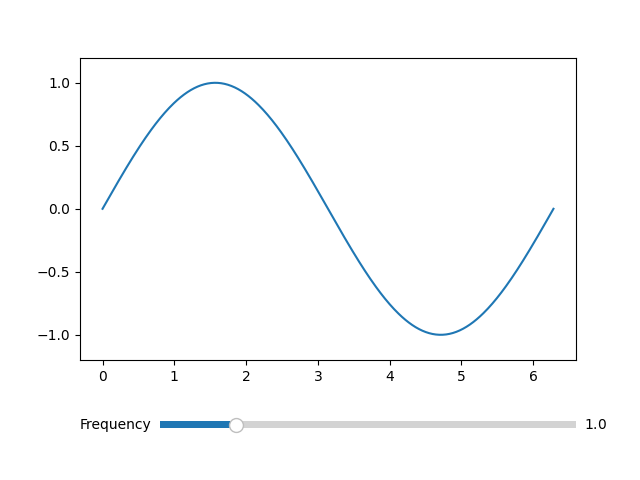

In [2]:
%matplotlib widget
import numpy as np, matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# create the graph
x = np.linspace(0, 2*np.pi, 400)
fig, ax = plt.subplots()
(line,) = ax.plot(x, np.sin(x))
ax.set_ylim(-1.2, 1.2)
plt.subplots_adjust(bottom=0.25) # leave some space in the bottom

# Create another axes for the slider
axfreq = plt.axes([0.25, 0.1, 0.65, 0.03])

# create slider
freq_slider = Slider(ax=axfreq, label="Frequency", valmin=0.1, valmax=5, valinit=1.0)

# Create a function that changes frequency based on changes in slider widget
def update(val):
    line.set_ydata(np.sin(freq_slider.val*x))
    fig.canvas.draw_idle()

#'Attach' slider behavior to on-change function
freq_slider.on_changed(update)
plt.show()

Use ipywidgets (with ipympl) when:
- You want panel‑style controls outside the figure with modern notebook layout.With ipympl, **the Matplotlib canvas(figure) itself becomes a Jupyter widget (fig.canvas)** that you can place into VBox/HBox along with sliders, dropdowns, etc.—great for “dashboard‑like” UIs in JupyterLab. 
- Ipywidgets implements a two‑way comm protocol between the Python kernel and the front end, so widget state and plot updates stay synchronized; high‑level utilities like interact make parameter sweeps trivial. 
- You’re building teaching demos or parameter explorers. Sliders/buttons/dropdowns sit beside the plot and update artists in callbacks; with ipympl enabled via %matplotlib widget, the toolbar (pan/zoom/save) stays live inside the notebook.

Check out the following example,

In [3]:
%matplotlib widget
import numpy as np, matplotlib.pyplot as plt
import ipywidgets as ipw

# With ipympl figures auto‑display when created 
plt.ioff()

# create the graph
x = np.linspace(0, 2*np.pi, 400)
fig, ax = plt.subplots()
(line,) = ax.plot(x, np.sin(x)) # NB. 'Capture' the line
ax.set_ylim(-1.2, 1.2)

# Create a  slider widget that controls frequency
freq = ipw.FloatSlider(description='freq', min=0.1, max=5, step=0.1, value=1.0)

# Create a function that changes frequency based on changes in slider widget
def on_change(change):
    line.set_ydata(np.sin(change["new"] * x))
    fig.canvas.draw_idle()

#'Attach' slider behavior to on-change function
freq.observe(on_change, names="value")

# create a vertical box widget where we put  slider above the figure canvas 
ipw.VBox([freq, fig.canvas])

## Working with Notebook Widgets `ipywidgets`

For the remaining of this tutorial we are going to be working only on interaction using Notebook widgets.

## The Standard Setup Pattern

When building any interactive widget UI, you follow these steps:

1. **Create the widgets** — instantiate sliders, dropdowns, buttons, etc. with initial values.
2. **Create an output area** — usually a `widgets.Output()` or a label that will display results.
3. **Write callback functions** — functions that read widget values and update the output.
4. **Register callbacks** — attach callbacks to widgets via `.observe(fn, names='value')` or `.on_click(fn)`.
5. **Arrange the layout** — use `HBox`, `VBox`, or `GridBox` to compose widgets into a visual layout.
6. **Display** — call `display(layout)` or put the layout object as the last expression in a cell.

In [4]:
import ipywidgets as iw
from IPython.display import display # Important

rng= np.random.default_rng(2026)

### Displaying Widgets

Widgets have their own display representation which allows them to be shown using IPython's display framework.

***Implicit display***

Constructing and returning a widget as the **last expression** in a cell automatically displays it. The widget appears in the output area below the code cell. Clearing cell output will also remove the widget.

In [5]:
# slider
iw.IntSlider()


IntSlider(value=0)

***Explicit display***

You can also explicitly display a widget by passing it to `display()`. This is useful when you want to display a widget that is not the last expression in a cell, or when you want to store a reference to the widget first.

In [6]:
# slider
w = iw.IntSlider()
display(w)

IntSlider(value=0)

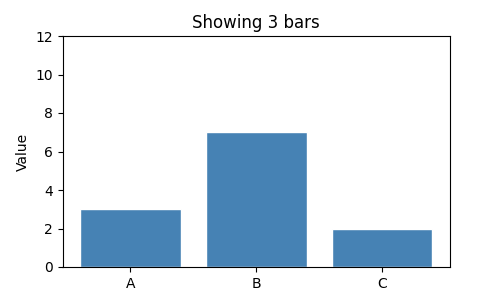

In [7]:
# data
categories = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
values     = [3, 7, 2, 9, 4, 6, 8, 5]


# A slider that controls how many bars are shown in the chart
n_slider = iw.IntSlider(value=3, min=1, max=8, description='# Bars:')

# widget captures output
out = iw.Output()

# define that function that updates slider value
def update(change):
    n = change['new'] # use the new value as the number of bars we want to display
    out.clear_output(wait=True) # clear output
    with out:
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.bar(categories[:n], values[:n], color='steelblue', edgecolor='white')
        ax.set_title(f'Showing {n} bar{"s" if n > 1 else ""}')
        ax.set_ylim(0, 12)
        ax.set_ylabel('Value')
        plt.show()

# link our callback function 
n_slider.observe(update, names='value')

# initialize output. We need to give it 'new' because that's what it uses
update({'new':n_slider.value})
# create a vertical box to combine slider and output
vb = iw.VBox([n_slider, out])

# display results 
display(vb)

### Widget Properties

All ipywidgets share a similar naming scheme and a common set of core properties.

***Reading `value`***

To read the current value of a widget, query its `value` property.

In [8]:
w = iw.IntSlider(value=3, min=0, max=10)
display(w)

IntSlider(value=3, max=10)

In [10]:
# what is the last value 
print(f"Current value: {w.value}")

Current value: 3


***Setting `value`***

Similarly, you can set the value of a widget by assigning to its `value` property. This will also update the visual representation in the browser.

In [15]:
w = iw.IntSlider(min=0, max=10)
display(w)

IntSlider(value=0, max=10)

In [16]:
# Programmatically move the slider to 7
w.value = 7

***Shared properties: `keys`, `description`, `disabled`***

In addition to `value`, most widgets share these common traits:

| Property | Description |
|----------|-------------|
| `value` | The current value of the widget |
| `description` | A text label displayed next to the widget |
| `disabled` | If `True`, the widget is greyed out and unresponsive |
| `keys` | A list of all synchronized, stateful properties for that widget |

To see the full list of synchronized properties for any specific widget, query its `keys` property.

In [17]:
w = iw.IntSlider()

In [18]:
print("All synchronized properties of IntSlider:")
w.keys

All synchronized properties of IntSlider:


['_dom_classes',
 '_model_module',
 '_model_module_version',
 '_model_name',
 '_view_count',
 '_view_module',
 '_view_module_version',
 '_view_name',
 'behavior',
 'continuous_update',
 'description',
 'description_allow_html',
 'disabled',
 'layout',
 'max',
 'min',
 'orientation',
 'readout',
 'readout_format',
 'step',
 'style',
 'tabbable',
 'tooltip',
 'value']

```{note}
Not all traits will display in a notebook
```
The `disabled` property

In [23]:
iw.Text(
    value='Hello World!',
    placeholder='Type something',
    description='Enter Text:',
    disabled= False
)

Text(value='Hello World!', description='Enter Text:', placeholder='Type something')

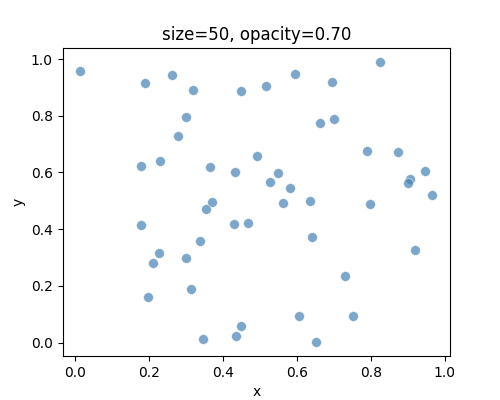

In [24]:
x = rng.random(50)
y = rng.random(50)

# Two sliders controlling plot properties
size_slider  = iw.IntSlider(value=50, min=10, max=200, step=10,
                                  description='Point size:',
                                  style={'description_width': 'initial'})
alpha_slider = iw.FloatSlider(value=0.7, min=0.1, max=1.0, step=0.05,
                                    description='Opacity:',
                                    style={'description_width': 'initial'})
out = iw.Output()

# callback function
def update(change=None):
    out.clear_output(wait=True)
    with out:
        fig, ax = plt.subplots(figsize=(5, 4))
        ax.scatter(x, y,
                   s=size_slider.value,
                   alpha=alpha_slider.value,
                   color='steelblue', edgecolors='white', linewidths=0.5)
        ax.set_title(f'size={size_slider.value}, opacity={alpha_slider.value:.2f}')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        plt.show()

# link the observer with the callback function
size_slider.observe(update, names='value')
alpha_slider.observe(update, names='value')

# initialize the output
update()

display(iw.VBox([size_slider, alpha_slider, out]))

### Setting Initial Values via the Constructor

While creating a widget, you can set some or all of the initial values by passing them as **keyword arguments** in the constructor.

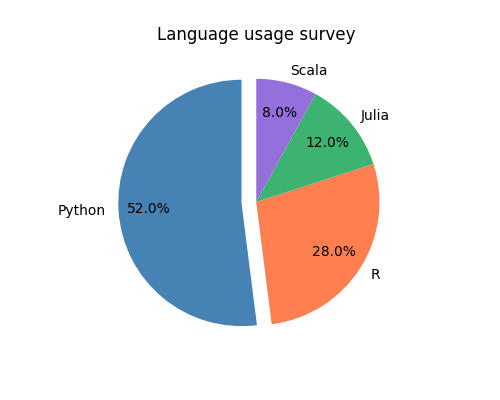

In [25]:
# Data
labels  = ['Python', 'R', 'Julia', 'Scala']
sizes   = [52, 28, 12, 8]
colors  = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']


# All meaningful values set at construction time via keyword arguments

start_angle  = iw.IntSlider(
    value=90, min=0, max=360, step=10,
    description='Start angle:',
    style={'description_width': 'initial'},
    continuous_update=False
)
explode_slice = iw.IntSlider(
    value=0, min=0, max=3, step=1,
    description='Explode slice:',
    style={'description_width': 'initial'},
    continuous_update=False
)
show_labels = iw.Checkbox(
    value=True,
    description='Show labels',
    disabled=False
)

out = iw.Output()

def update(change=None):
    explode = [0] * 4
    explode[explode_slice.value] = 0.12 

    out.clear_output(wait=True)
    with out:
        fig, ax = plt.subplots(figsize=(5, 4))
        ax.pie(
            sizes,
            labels=labels if show_labels.value else None,
            colors=colors,
            explode=explode,
            startangle=start_angle.value,
            autopct='%1.1f%%',
            pctdistance=0.75
        )
        ax.set_title('Language usage survey')
        plt.show()

# Link observer wth each callback
start_angle.observe(update, names='value')
explode_slice.observe(update, names='value')
show_labels.observe(update, names='value')

update()   # initial render uses the constructor values defined above

display(iw.VBox([
    iw.HBox([start_angle, explode_slice]),
    show_labels,
    out
]))

### Linking Widgets

If you need to display the same value in two different ways, you need two separate widget instances — you cannot just display the same widget twice expecting different visual styles.

Instead of manually synchronizing values, use `widgets.link()` or `widgets.jslink()` to keep two widget properties in sync automatically.

| Function | How it works |
|----------|--------------|
| `widgets.link()` | Synchronizes via the Python kernel — flexible but slightly slower |
| `widgets.jslink()` | Synchronizes entirely in JavaScript in the browser — faster, no kernel round-trip |

Let's consider the following example where we link a `FloatText` and a `FloatSlider`. Changing either widget below will instantly update the other.

In [26]:
a = iw.FloatText(description='Float Text:')
b = iw.FloatSlider(description='Float Slider:')
display(a, b)

# here is the link
mylink = iw.jslink((a,'value'), (b,'value'))

FloatText(value=0.0, description='Float Text:')

FloatSlider(value=0.0, description='Float Slider:')

***Unlinking***

Unlinking is simple. Call `.unlink()` on the link object and the two widgets become independent again.

In [27]:
# Run this cell to break the link between the widgets above
mylink.unlink()
print("Link broken. The two widgets are now independent.")

Link broken. The two widgets are now independent.


***`link` vs `jslink` in practice***

The example below uses `widgets.link()` (Python-side) to demonstrate the difference. The behaviour for the end user looks the same, but Python-side linking lets you observe and react to changes in your callback functions.

In [29]:
c = iw.IntSlider(description='Source:', min=0, max=100, value=42)
d = iw.IntText(description='Mirror:')
display(c, d)

# Python-side two-way link
python_link = iw.link((c, 'value'), (d, 'value'))

# To unlink:
# python_link.unlink()

IntSlider(value=42, description='Source:')

IntText(value=0, description='Mirror:')

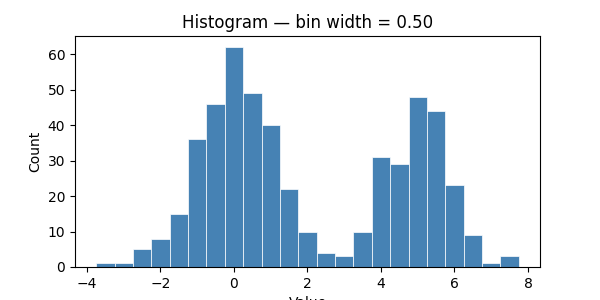

In [28]:
# Data
data = np.concatenate([
    rng.normal(loc=0,  scale=1,   size=300),
    rng.normal(loc=5,  scale=0.8, size=200)
])

# A FloatText and FloatSlider linked together — change one, the other follows
text_input = iw.FloatText(
    value=0.5, min=0.1, max=2.0,
    description='Bin width:',
    style={'description_width': 'initial'},
    step=0.1
)
slider_input = iw.FloatSlider(
    value=0.5, min=0.1, max=2.0,
    description='Bin width:',
    style={'description_width': 'initial'},
    step=0.1,
    continuous_update=False
)

# jslink keeps them in sync purely in the browser — no kernel round-trip
link = iw.jslink((text_input, 'value'), (slider_input, 'value'))

out = iw.Output()

def update(change=None):
    bin_width = slider_input.value
    bins = np.arange(data.min(), data.max() + bin_width, bin_width)
    out.clear_output(wait=True)
    with out:
        fig, ax = plt.subplots(figsize=(6, 3))
        ax.hist(data, bins=bins, color='steelblue',
                edgecolor='white', linewidth=0.5)
        ax.set_title(f'Histogram — bin width = {bin_width:.2f}', size= 12)
        ax.set_xlabel('Value')
        ax.set_ylabel('Count')
        plt.show()

# Both iw share the same callback via the slider
# (since jslink keeps them in sync, only one observe is needed)
slider_input.observe(update, names='value')
update()

unlink_btn = iw.Button(
    description='Unlink Widgets',
    button_style='warning',
    icon='chain-broken'
)

def on_unlink(b):
    link.unlink()
    unlink_btn.disabled = True
    unlink_btn.description = 'Unlinked ✓'

unlink_btn.on_click(on_unlink)

display(iw.VBox([
                iw.HBox([text_input, slider_input]),
                out,
                unlink_btn
                ])
       )